In [212]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [213]:
pip install dice-ml

In [214]:
pip install category-encoders

In [215]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, FunctionTransformer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from category_encoders import TargetEncoder


import dice_ml
from dice_ml import Dice

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import dice_ml
import shap
#metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay,
                            classification_report, roc_auc_score, confusion_matrix, confusion_matrix, auc, roc_curve, RocCurveDisplay)

#model exporter
import joblib
import os

In [216]:
pd.options.future.infer_string = True

In [217]:
df = pd.read_csv("/content/drive/MyDrive/customer_churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   string 
 1   gender            7043 non-null   string 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   string 
 4   Dependents        7043 non-null   string 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   string 
 7   MultipleLines     7043 non-null   string 
 8   InternetService   7043 non-null   string 
 9   OnlineSecurity    7043 non-null   string 
 10  OnlineBackup      7043 non-null   string 
 11  DeviceProtection  7043 non-null   string 
 12  TechSupport       7043 non-null   string 
 13  StreamingTV       7043 non-null   string 
 14  StreamingMovies   7043 non-null   string 
 15  Contract          7043 non-null   string 
 16  PaperlessBilling  7043 non-null   string 


In [218]:
df.duplicated().sum()

np.int64(0)

In [219]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [220]:
df.select_dtypes(include="string").nunique()

,0
customerID,7043
gender,2
Partner,2
Dependents,2
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3
OnlineBackup,3
DeviceProtection,3


In [221]:
df.shape

(7043, 21)

In [222]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [223]:
df["SeniorCitizen"].unique()

array([0, 1])

#### Data Cleaning

In [224]:
#Drop the customer id column
df.drop(columns=["customerID"], inplace=True)

In [225]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [226]:
cat_cols = list(df.select_dtypes(include="string").columns)

In [227]:
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'TotalCharges',
 'Churn']

In [228]:
#Remove all extra white spaces in all categorical columns column
df[cat_cols] = df[cat_cols].apply(lambda x: x.str.strip())

In [229]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [230]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
TotalCharges,11


In [231]:
df['TotalCharges'].mean(), df['TotalCharges'].median()

(np.float64(2283.3004408418656), 1397.475)

**The difference in the mean and median means that the data is skewed (there are outliers in the TotalCharges column).**

In [232]:
# Handle missing values
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [233]:
df.isnull().sum()[df.isnull().sum() > 0]

,0


In [234]:
# Standardize categorical values
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: "Yes", 0: "No"})

In [235]:
df['SeniorCitizen'].unique()

<ArrowStringArrayNumpySemantics>
['No', 'Yes']
Length: 2, dtype: string

In [236]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [237]:
df_raw = df.copy()

#### Exploratory Data Analysis(EDA)

In [238]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='string')

##### Univariate Analysis - Categorical Variables

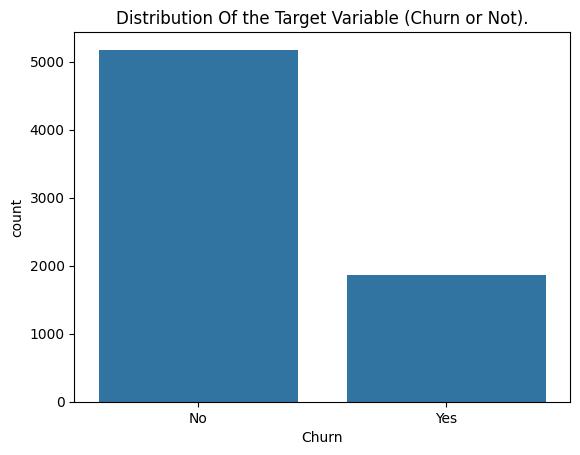

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [239]:
sns.countplot(x="Churn", data=df)
plt.title("Distribution Of the Target Variable (Churn or Not).")
plt.show()

print(df['Churn'].value_counts(normalize=True))

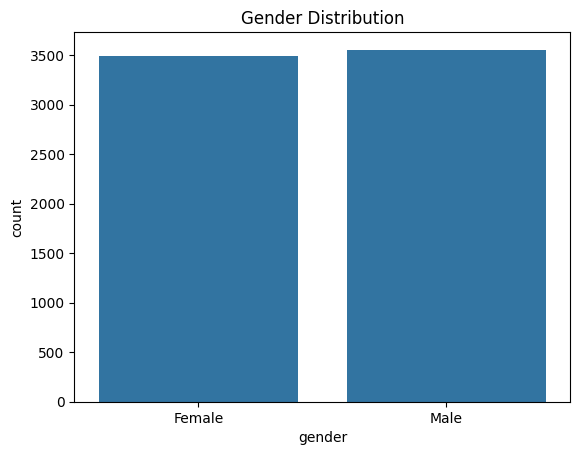

gender
Male      0.504756
Female    0.495244
Name: proportion, dtype: float64


In [240]:
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.show()

print(df['gender'].value_counts(normalize=True))

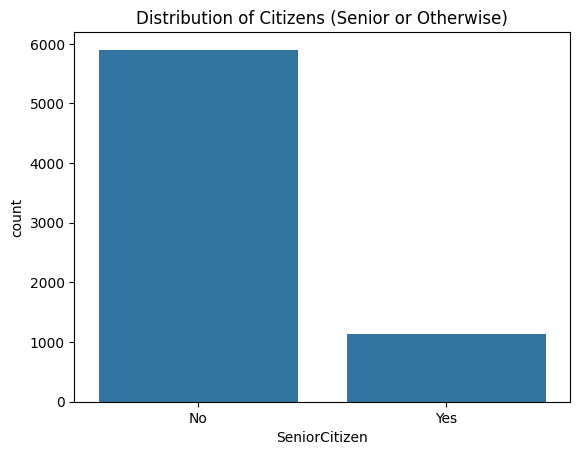

SeniorCitizen
No     0.837853
Yes    0.162147
Name: proportion, dtype: float64


In [241]:
sns.countplot(x="SeniorCitizen", data=df)
plt.title("Distribution of Citizens (Senior or Otherwise)")
plt.show()

print(df['SeniorCitizen'].value_counts(normalize=True))

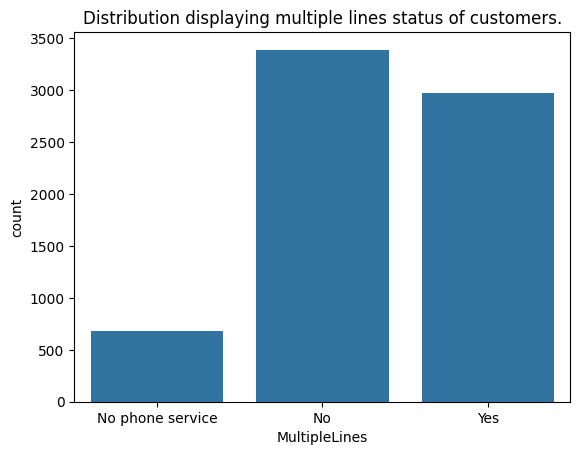

MultipleLines
No                  0.481329
Yes                 0.421837
No phone service    0.096834
Name: proportion, dtype: float64


In [242]:
sns.countplot(x="MultipleLines", data=df)
plt.title("Distribution displaying multiple lines status of customers.")
plt.show()

print(df['MultipleLines'].value_counts(normalize=True))

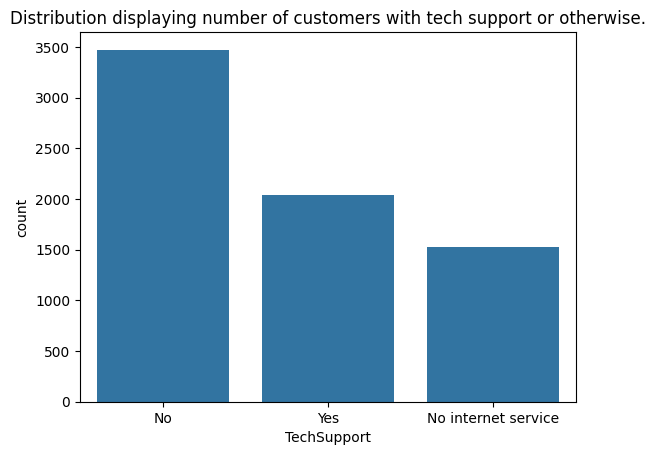

TechSupport
No                     0.493114
Yes                    0.290217
No internet service    0.216669
Name: proportion, dtype: float64


In [243]:
sns.countplot(x="TechSupport", data=df)
plt.title("Distribution displaying number of customers with tech support or otherwise.")
plt.show()

print(df['TechSupport'].value_counts(normalize=True))

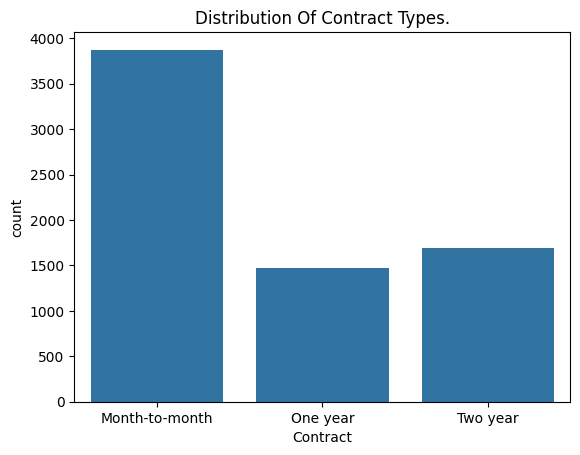

Contract
Month-to-month    0.550192
Two year          0.240664
One year          0.209144
Name: proportion, dtype: float64


In [244]:
sns.countplot(x="Contract", data=df)
plt.title("Distribution Of Contract Types.")
plt.show()

print(df['Contract'].value_counts(normalize=True))

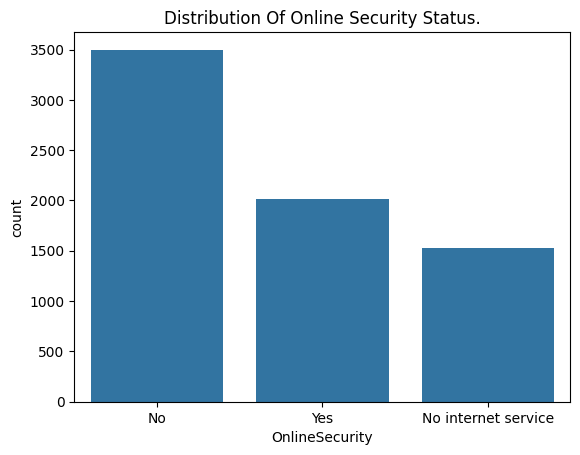

OnlineSecurity
No                     0.496663
Yes                    0.286668
No internet service    0.216669
Name: proportion, dtype: float64


In [245]:
sns.countplot(x="OnlineSecurity", data=df)
plt.title("Distribution Of Online Security Status.")
plt.show()

print(df['OnlineSecurity'].value_counts(normalize=True))

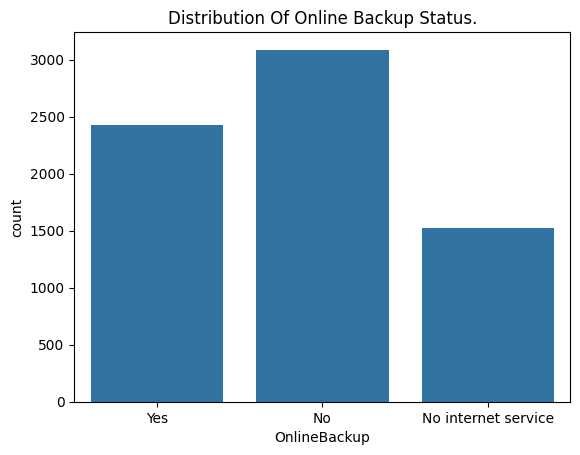

OnlineBackup
No                     0.438450
Yes                    0.344881
No internet service    0.216669
Name: proportion, dtype: float64


In [246]:
sns.countplot(x="OnlineBackup", data=df)
plt.title("Distribution Of Online Backup Status.")
plt.show()

print(df['OnlineBackup'].value_counts(normalize=True))

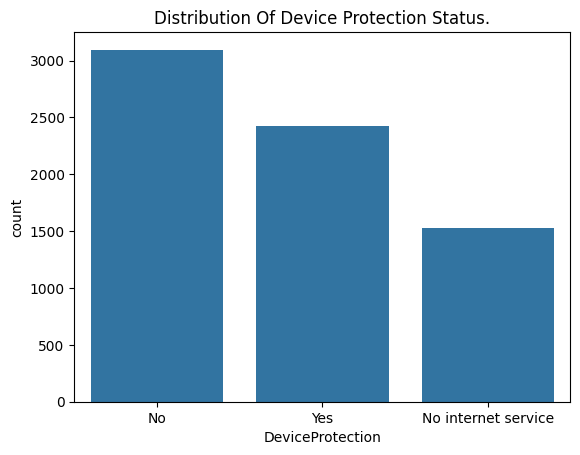

DeviceProtection
No                     0.439443
Yes                    0.343888
No internet service    0.216669
Name: proportion, dtype: float64


In [247]:
sns.countplot(x="DeviceProtection", data=df)
plt.title("Distribution Of Device Protection Status.")
plt.show()

print(df['DeviceProtection'].value_counts(normalize=True))

##### Univariate Analysis - Numeric Variables

In [248]:
df[['tenure','MonthlyCharges','TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.916928
std,24.559481,30.090047,2265.270398
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,402.225000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


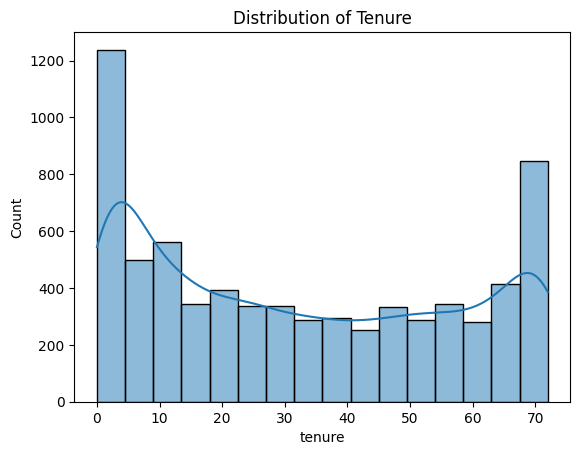

In [249]:
sns.histplot(df['tenure'], kde=True)
plt.title("Distribution of Tenure");

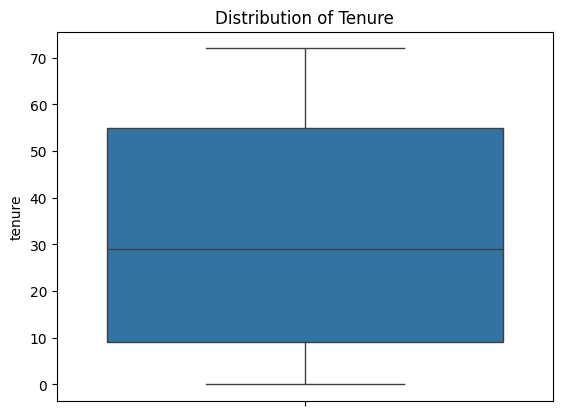

In [250]:
sns.boxplot(y='tenure', data=df)
plt.title("Distribution of Tenure");

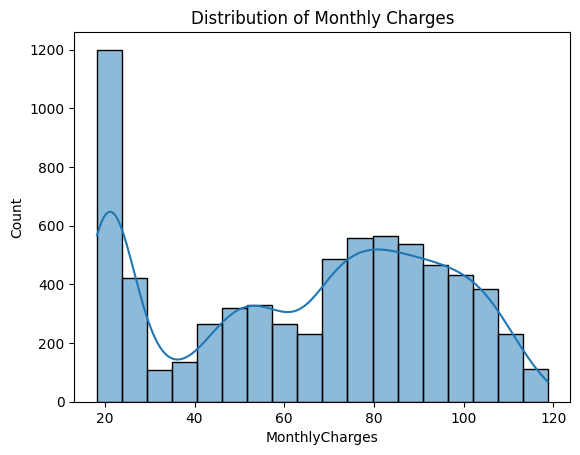

In [251]:
sns.histplot(df['MonthlyCharges'], kde=True)
plt.title("Distribution of Monthly Charges");

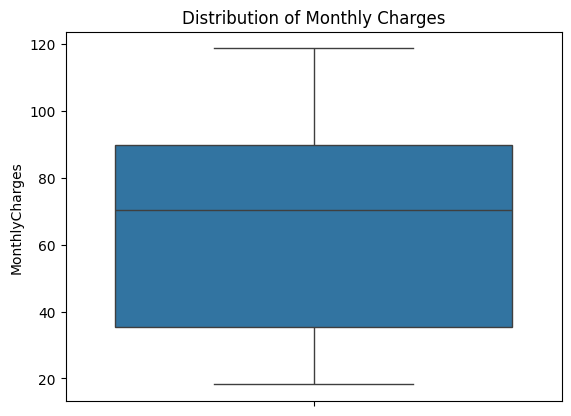

In [252]:
sns.boxplot(y='MonthlyCharges', data=df)
plt.title("Distribution of Monthly Charges");

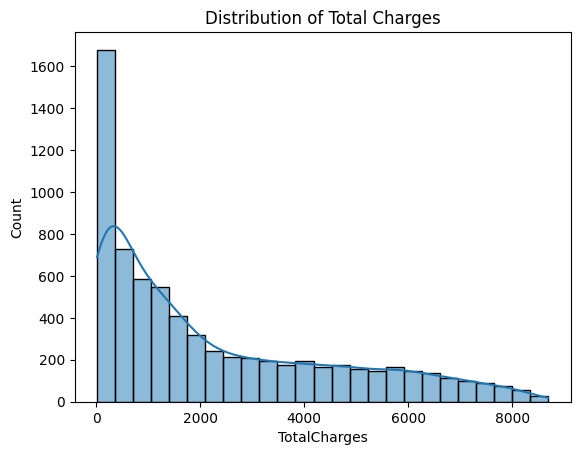

In [253]:
sns.histplot(df['TotalCharges'], kde=True)
plt.title("Distribution of Total Charges");

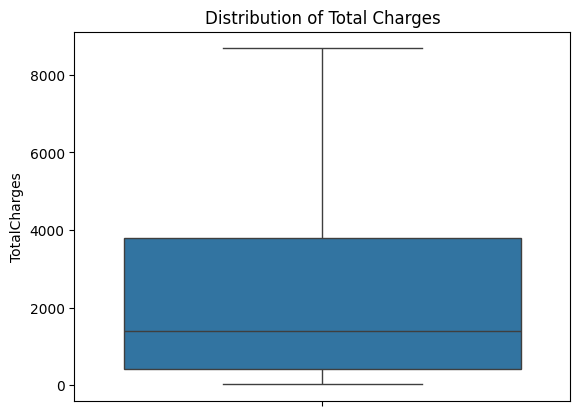

In [254]:
sns.boxplot(y='TotalCharges', data=df)
plt.title("Distribution of Total Charges");

##### Bivariate Analysis - Categorical Variables vs Churn

In [255]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='string')

gender  Churn
Female  No       73.08
        Yes      26.92
Male    No       73.84
        Yes      26.16
Name: proportion, dtype: float64

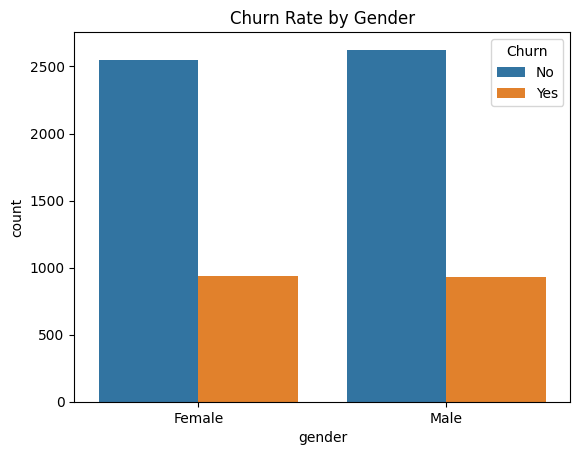

In [256]:
sns.countplot(x='gender', hue='Churn', data=df);
plt.title("Churn Rate by Gender");

(df.groupby(["gender"])["Churn"].value_counts(normalize=True) * 100).round(2)

SeniorCitizen  Churn
No             No       76.39
               Yes      23.61
Yes            No       58.32
               Yes      41.68
Name: proportion, dtype: float64

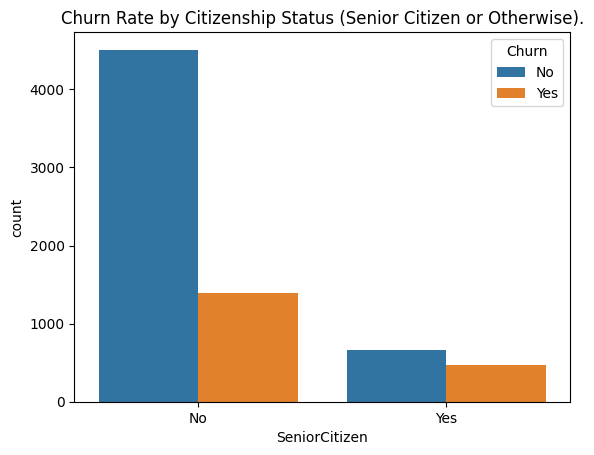

In [257]:
sns.countplot(x='SeniorCitizen', hue='Churn', data=df);
plt.title("Churn Rate by Citizenship Status (Senior Citizen or Otherwise).");

(df.groupby(["SeniorCitizen"])["Churn"].value_counts(normalize=True) * 100).round(2)

MultipleLines     Churn
No                No       74.96
                  Yes      25.04
No phone service  No       75.07
                  Yes      24.93
Yes               No       71.39
                  Yes      28.61
Name: proportion, dtype: float64

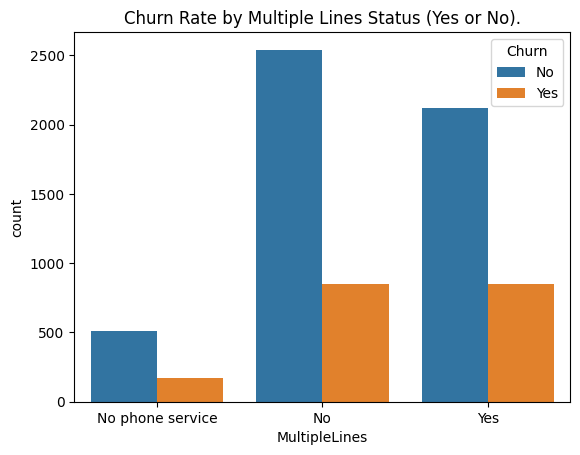

In [258]:
sns.countplot(x='MultipleLines', hue='Churn', data=df);
plt.title("Churn Rate by Multiple Lines Status (Yes or No).");

(df.groupby(["MultipleLines"])["Churn"].value_counts(normalize=True) * 100).round(2)

In [259]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='string')

TechSupport          Churn
No                   No       58.36
                     Yes      41.64
No internet service  No       92.60
                     Yes       7.40
Yes                  No       84.83
                     Yes      15.17
Name: proportion, dtype: float64

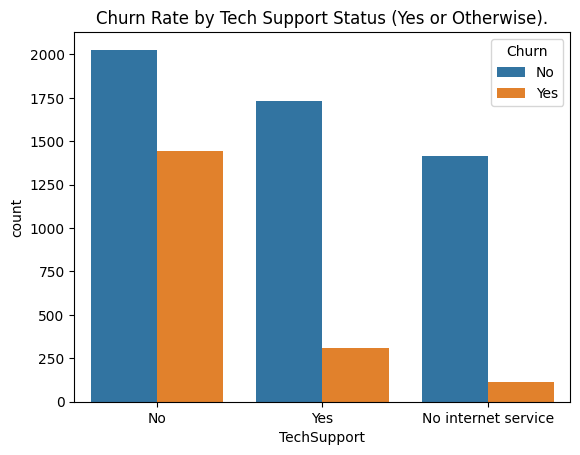

In [260]:
sns.countplot(x='TechSupport', hue='Churn', data=df);
plt.title("Churn Rate by Tech Support Status (Yes or Otherwise).");

(df.groupby(["TechSupport"])["Churn"].value_counts(normalize=True) * 100).round(2)

Contract        Churn
Month-to-month  No       57.29
                Yes      42.71
One year        No       88.73
                Yes      11.27
Two year        No       97.17
                Yes       2.83
Name: proportion, dtype: float64

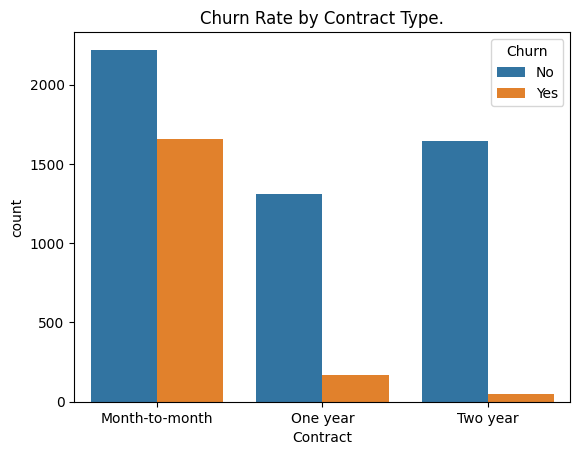

In [261]:
sns.countplot(x='Contract', hue='Churn', data=df);
plt.title("Churn Rate by Contract Type.");

(df.groupby(["Contract"])["Churn"].value_counts(normalize=True) * 100).round(2)

OnlineSecurity       Churn
No                   No       58.23
                     Yes      41.77
No internet service  No       92.60
                     Yes       7.40
Yes                  No       85.39
                     Yes      14.61
Name: proportion, dtype: float64

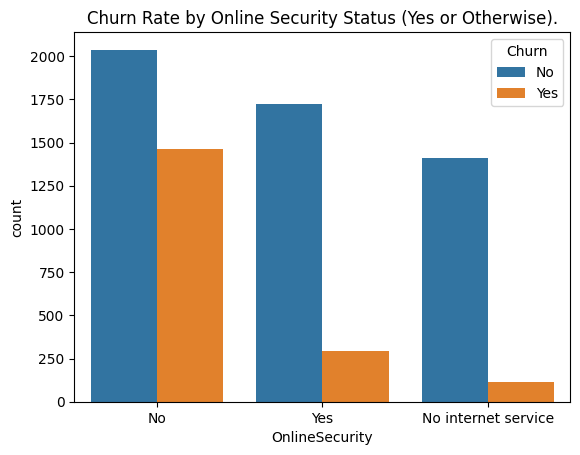

In [262]:
sns.countplot(x='OnlineSecurity', hue='Churn', data=df);
plt.title("Churn Rate by Online Security Status (Yes or Otherwise).");

(df.groupby(["OnlineSecurity"])["Churn"].value_counts(normalize=True) * 100).round(2)

OnlineBackup         Churn
No                   No       60.07
                     Yes      39.93
No internet service  No       92.60
                     Yes       7.40
Yes                  No       78.47
                     Yes      21.53
Name: proportion, dtype: float64

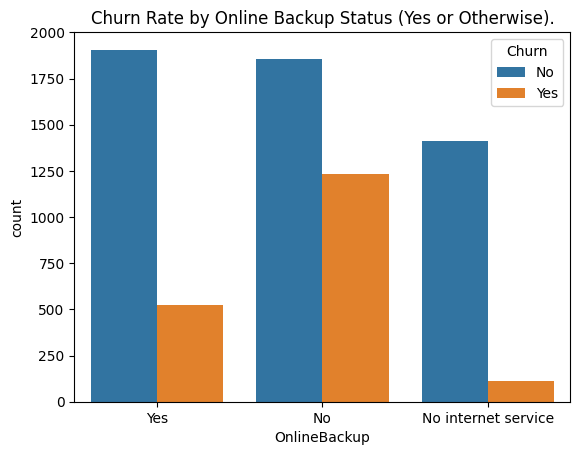

In [263]:
sns.countplot(x='OnlineBackup', hue='Churn', data=df);
plt.title("Churn Rate by Online Backup Status (Yes or Otherwise).");

(df.groupby(["OnlineBackup"])["Churn"].value_counts(normalize=True) * 100).round(2)

DeviceProtection     Churn
No                   No       60.87
                     Yes      39.13
No internet service  No       92.60
                     Yes       7.40
Yes                  No       77.50
                     Yes      22.50
Name: proportion, dtype: float64

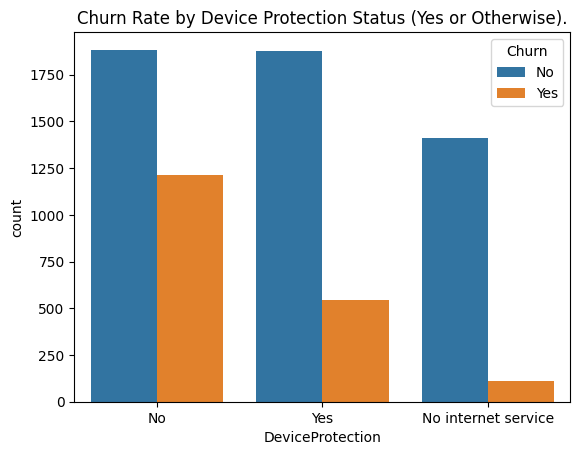

In [264]:
sns.countplot(x='DeviceProtection', hue='Churn', data=df);
plt.title("Churn Rate by Device Protection Status (Yes or Otherwise).");

(df.groupby(["DeviceProtection"])["Churn"].value_counts(normalize=True) * 100).round(2)

##### Bivariate Analysis - Numeric Variables vs Churn

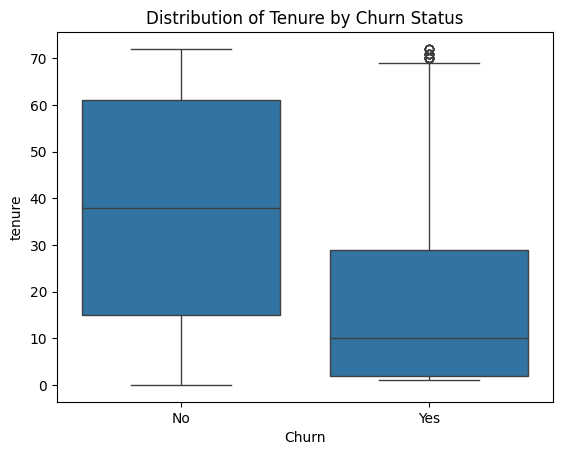

In [265]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Distribution of Tenure by Churn Status");

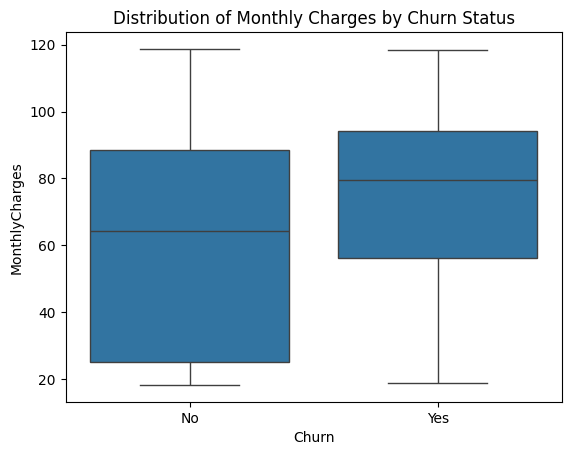

In [266]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Distribution of Monthly Charges by Churn Status");

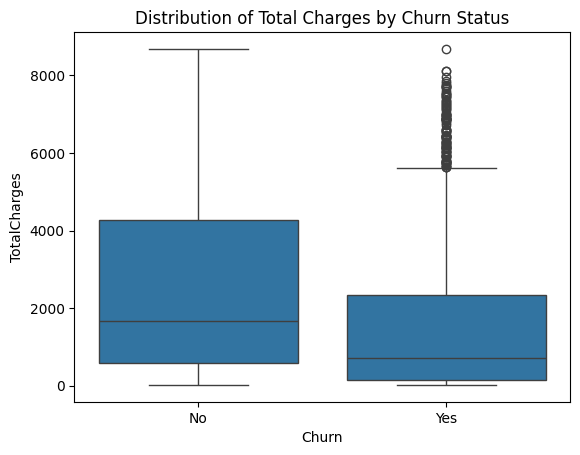

In [267]:
sns.boxplot(x='Churn', y='TotalCharges', data=df)
plt.title("Distribution of Total Charges by Churn Status");

#### Data Preprocessing

In [268]:
df1 = df.copy()

In [269]:
df1.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='string')

In [270]:
len(df1.dtypes[df1.dtypes.values == "str"])

0

In [271]:
categorical_cols = df1.select_dtypes(include="string").columns

In [272]:
numeric_cols = df1.select_dtypes(include="number").columns

In [273]:
len(categorical_cols)

17

In [274]:
len(numeric_cols)

3

In [275]:
encoders = {}
mappings = {}

for col in categorical_cols:
    le = LabelEncoder()
    df1[col] = le.fit_transform(df1[col])


    encoders[col] = le # Store the encoder object
    mappings[col] = dict(zip(le.classes_, range(len(le.classes_)))) #Create a dictionary of the specific mapping for this column

In [276]:
mappings

{'gender': {'Female': 0, 'Male': 1},
 'SeniorCitizen': {'No': 0, 'Yes': 1},
 'Partner': {'No': 0, 'Yes': 1},
 'Dependents': {'No': 0, 'Yes': 1},
 'PhoneService': {'No': 0, 'Yes': 1},
 'MultipleLines': {'No': 0, 'No phone service': 1, 'Yes': 2},
 'InternetService': {'DSL': 0, 'Fiber optic': 1, 'No': 2},
 'OnlineSecurity': {'No': 0, 'No internet service': 1, 'Yes': 2},
 'OnlineBackup': {'No': 0, 'No internet service': 1, 'Yes': 2},
 'DeviceProtection': {'No': 0, 'No internet service': 1, 'Yes': 2},
 'TechSupport': {'No': 0, 'No internet service': 1, 'Yes': 2},
 'StreamingTV': {'No': 0, 'No internet service': 1, 'Yes': 2},
 'StreamingMovies': {'No': 0, 'No internet service': 1, 'Yes': 2},
 'Contract': {'Month-to-month': 0, 'One year': 1, 'Two year': 2},
 'PaperlessBilling': {'No': 0, 'Yes': 1},
 'PaymentMethod': {'Bank transfer (automatic)': 0,
  'Credit card (automatic)': 1,
  'Electronic check': 2,
  'Mailed check': 3},
 'Churn': {'No': 0, 'Yes': 1}}

In [277]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  


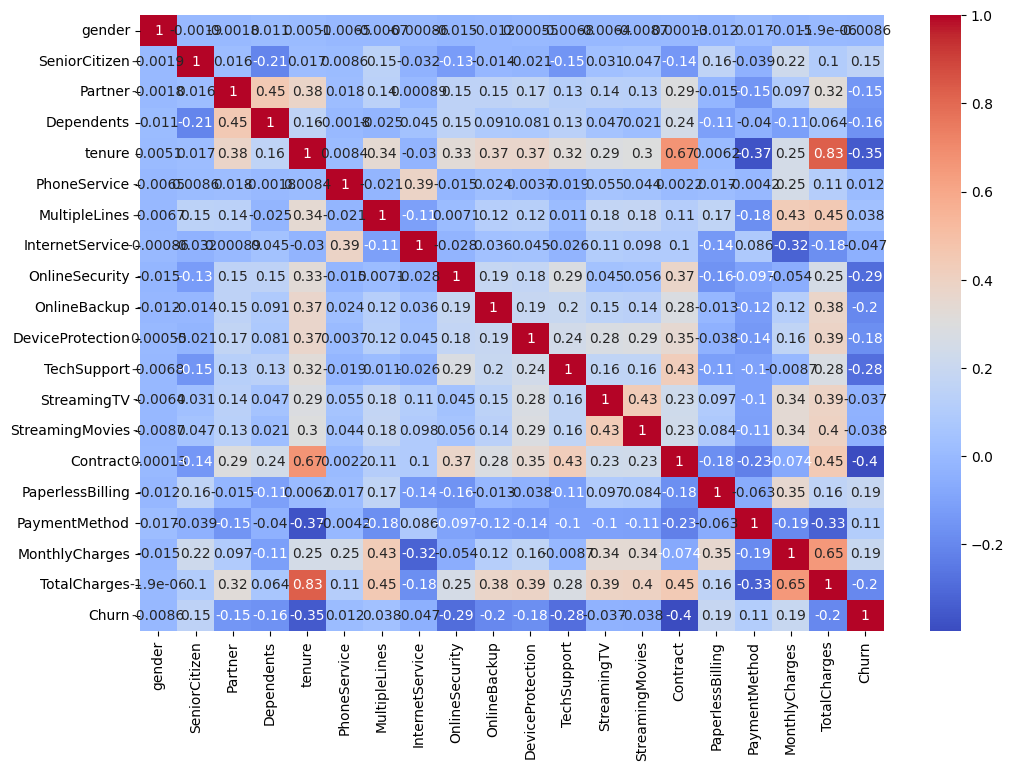

In [278]:
plt.figure(figsize=(12, 8))
sns.heatmap(df1.corr(), annot=True, cmap="coolwarm");

In [279]:
df1.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [280]:
X = df1.drop("Churn", axis=1)
y = df1["Churn"]

In [281]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [282]:
X_train.shape

(4930, 19)

In [283]:
print("Before Oversampling:")
y_train.value_counts()

Before Oversampling:


,count
Churn,
0,3622
1,1308


#### Applying SMOTE

In [284]:
# For oversampling of minority class
sm = SMOTE()

# Fit predictor (x variable)
# and target (y variable) using fit_resample()
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

In [285]:
X_train_smote.shape

(7244, 19)

In [286]:
X_train_smote.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,0,0,5,1,0,1,0,0,0,0,2,0,0,0,2,80.20,384.25
1,0,1,0,0,3,1,0,1,0,0,2,0,2,0,0,1,2,86.85,220.95
2,0,0,1,0,3,1,2,1,0,0,0,0,0,0,0,1,1,75.15,216.75
3,0,0,0,0,60,1,2,0,0,0,2,2,2,2,1,0,1,80.55,4847.05
4,0,0,0,0,12,1,0,1,2,0,0,2,2,2,0,1,0,98.90,1120.95


In [287]:
y_train_smote.shape

(7244,)

In [288]:
y_train_smote.value_counts()

,count
Churn,
0,3622
1,3622


In [289]:
scaler = StandardScaler()
scaler.set_output(transform='pandas')

StandardScaler()

In [290]:
cols_fit = ["tenure", "MonthlyCharges", "TotalCharges"]

In [291]:
X_train_smote_cols_fit_scaled = scaler.fit_transform(X_train_smote[cols_fit])
X_test_scaled = scaler.transform(X_test[cols_fit])

In [292]:
X_train_smote[["tenure", "MonthlyCharges", "TotalCharges"]] = X_train_smote_cols_fit_scaled
X_test[["tenure", "MonthlyCharges", "TotalCharges"]] = X_test_scaled

In [293]:
X_train_smote.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,0,0,-0.941136,1,0,1,0,0,0,0,2,0,0,0,2,0.416592,-0.759718
1,0,1,0,0,-1.024266,1,0,1,0,0,2,0,2,0,0,1,2,0.648236,-0.833914
2,0,0,1,0,-1.024266,1,2,1,0,0,0,0,0,0,0,1,1,0.240682,-0.835823
3,0,0,0,0,1.344917,1,2,0,0,0,2,2,2,2,1,0,1,0.428784,1.267984
4,0,0,0,0,-0.650184,1,0,1,2,0,0,2,2,2,0,1,0,1.067981,-0.424994


In [294]:
X_test.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
4994,0,0,0,0,-0.400797,1,0,1,2,0,0,0,2,2,0,1,2,0.968705,-0.143406
6828,0,0,1,1,-0.816443,1,0,2,1,1,1,1,1,1,2,0,3,-1.713485,-0.842661
755,1,1,0,0,-0.317667,1,2,1,0,0,2,0,2,2,0,1,2,1.055789,-0.097016
404,1,0,0,0,-0.317667,1,0,2,1,1,1,1,1,1,2,1,3,-1.690843,-0.743747
981,1,0,1,1,0.513625,1,0,2,1,1,1,1,1,1,2,0,3,-1.694327,-0.566753


In [295]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

In [296]:
all_models = [
    ('Logistic Regression', log_reg),
    ('Random Forest', rf_clf),
    ('XGBoost', xgb_clf)
]

In [297]:
results_list = []

for name, model in all_models:

    model.fit(X_train_smote, y_train_smote)
    probs = model.predict_proba(X_test)[:, 1]

    # Make predictions
    preds = model.predict(X_test)

    # Calculate metrics
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)

    # Append to results
    results_list.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC AUC': round(auc, 4)
    })
    print(f"Finished evaluating: {name}")

# Create a summary DataFrame
results_df = pd.DataFrame(results_list).sort_values(by='F1-Score', ascending=False)

Finished evaluating: Logistic Regression
Finished evaluating: Random Forest


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:17:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Finished evaluating: XGBoost


In [298]:
print("\nModel Comparison Summary")
print(results_df)


Model Comparison Summary
                 Model  Accuracy  Precision  Recall  F1-Score  ROC AUC
0  Logistic Regression    0.7544     0.5268  0.7362    0.6141   0.8245
1        Random Forest    0.7738     0.5729  0.5811    0.5770   0.8100
2              XGBoost    0.7648     0.5569  0.5579    0.5574   0.8073


### **Implementing DiCE and Logistic Regression with the original dataframe**

In [299]:
df_raw.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [300]:
# Separate features and target
X1 = df_raw.drop(columns=["Churn"])
y1 = df_raw["Churn"]

# Define feature types
continuous_features = ["tenure", "MonthlyCharges", "TotalCharges"]

categorical_features = [
    col for col in X1.columns
    if col not in continuous_features
]

In [301]:
# Train test split
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1,
    y1,
    test_size=0.2,
    random_state=42,
    stratify=y1
)

##### **Build preprocessing and model pipeline**

In [302]:
mappings2 = mappings.copy()

In [303]:
mappings2.pop("Churn")

{'No': 0, 'Yes': 1}

In [304]:
mappings2

{'gender': {'Female': 0, 'Male': 1},
 'SeniorCitizen': {'No': 0, 'Yes': 1},
 'Partner': {'No': 0, 'Yes': 1},
 'Dependents': {'No': 0, 'Yes': 1},
 'PhoneService': {'No': 0, 'Yes': 1},
 'MultipleLines': {'No': 0, 'No phone service': 1, 'Yes': 2},
 'InternetService': {'DSL': 0, 'Fiber optic': 1, 'No': 2},
 'OnlineSecurity': {'No': 0, 'No internet service': 1, 'Yes': 2},
 'OnlineBackup': {'No': 0, 'No internet service': 1, 'Yes': 2},
 'DeviceProtection': {'No': 0, 'No internet service': 1, 'Yes': 2},
 'TechSupport': {'No': 0, 'No internet service': 1, 'Yes': 2},
 'StreamingTV': {'No': 0, 'No internet service': 1, 'Yes': 2},
 'StreamingMovies': {'No': 0, 'No internet service': 1, 'Yes': 2},
 'Contract': {'Month-to-month': 0, 'One year': 1, 'Two year': 2},
 'PaperlessBilling': {'No': 0, 'Yes': 1},
 'PaymentMethod': {'Bank transfer (automatic)': 0,
  'Credit card (automatic)': 1,
  'Electronic check': 2,
  'Mailed check': 3}}

In [305]:
# Custom mapping function
def apply_mappings(X):
    X = X.copy()
    for col, mapping in mappings2.items():
        if col in X.columns:
            # Ensure values are strings before replacement
            X[col] = X[col].astype(str).replace(mapping)
    return X

# Wrap in FunctionTransformer
mapper = FunctionTransformer(apply_mappings, validate=False)

# Define feature groups
categorical_features = list(mappings2.keys())
continuous_features = ["tenure", "MonthlyCharges", "TotalCharges"]  # adjust to your dataset

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", mapper, categorical_features),
        ("num", "passthrough", continuous_features)
    ]
)

# Full pipeline
model_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# Encode target variable ("No"/"Yes" -> 0/1)
target_encoder = LabelEncoder()
y_train1_encoded = target_encoder.fit_transform(y_train1)
y_test1_encoded  = target_encoder.transform(y_test1)

In [306]:
mapping = dict(zip(target_encoder.classes_, range(len(target_encoder.classes_))))
print(mapping)

{'No': 0, 'Yes': 1}


In [307]:
joblib.dump(target_encoder, "/content/drive/MyDrive/customer_churn/target_encoder.pkl")

['/content/drive/MyDrive/customer_churn/target_encoder.pkl']

In [308]:
pd.set_option('future.no_silent_downcasting', True)

In [309]:
model_pipeline.fit(X_train1, y_train1_encoded)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  FunctionTransformer(func=<function apply_mappings at 0x791f052a05e0>),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('num', 'passthrough',
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('smote', SMOTE(random_state=42)), ('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [310]:
y_pred1 = model_pipeline.predict(X_test1)

print("Accuracy:", accuracy_score(y_test1_encoded, y_pred1))

print("\nClassification Report:")
print(classification_report(y_test1_encoded, y_pred1))

Accuracy: 0.7388218594748048

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409




Confusion Matrix:
[[743 292]
 [ 76 298]]


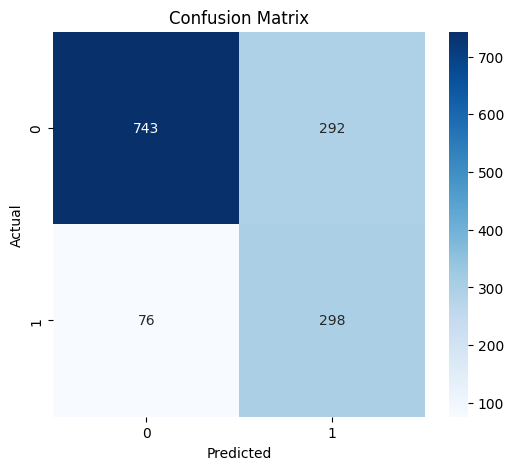

In [311]:
cm = confusion_matrix(y_test1_encoded, y_pred1)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

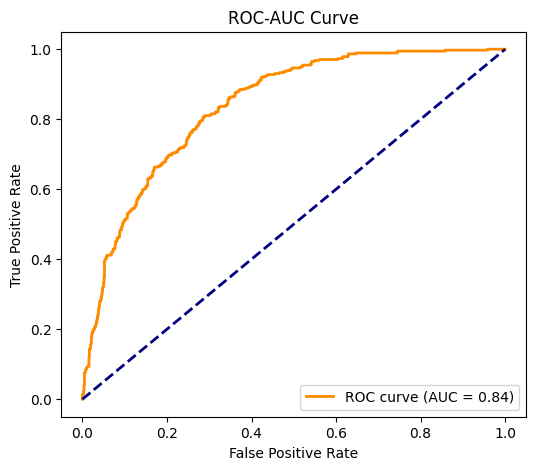

In [312]:
# ROC-AUC Curve
y_pred_proba = model_pipeline.predict_proba(X_test1)[:,1]  # probability for class 1
fpr, tpr, thresholds = roc_curve(y_test1_encoded, y_pred_proba)
roc_auc = roc_auc_score(y_test1, y_pred_proba)  # safer than auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend(loc="lower right")
plt.show()

In [313]:
dice_data = dice_ml.Data(
    dataframe=df_raw,
    continuous_features=continuous_features,
    outcome_name="Churn",
    immutable_features=['gender', 'SeniorCitizen', 'Partner', 'Dependents']
)

dice_model = dice_ml.Model(
    model=model_pipeline,
    backend="sklearn"
)

explainer = Dice(dice_data, dice_model)



In [314]:
features_to_vary = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "MonthlyCharges"
]

##### **A test run**

In [315]:
test_predictions = model_pipeline.predict(X_test1)

churn_customers = X_test1[test_predictions == 1]

query_instance = churn_customers.iloc[[0]]

query_instance

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
2280,Female,Yes,No,No,8,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55


In [316]:
dice_exp = explainer.generate_counterfactuals(
    query_instance,
    total_CFs=5,
    desired_class="opposite",
    features_to_vary=features_to_vary,
    permitted_range={
        "MonthlyCharges": [20, 120]
    }
)

dice_exp.visualize_as_dataframe()

100%|██████████| 1/1 [00:01<00:00,  1.82s/it]

Query instance (original outcome : 1)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,Yes,No,No,8,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.150002,908.549988,1



Diverse Counterfactual set (new outcome: 0)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,Yes,No,No,8,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,One year,Yes,Credit card (automatic),40.93,908.55,0
1,Female,Yes,No,No,8,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),70.11,908.55,0
2,Female,Yes,No,No,8,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),52.97,908.55,0
3,Female,Yes,No,No,8,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,One year,Yes,Credit card (automatic),32.58,908.55,0
4,Female,Yes,No,No,8,Yes,Yes,Fiber optic,Yes,No,No,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),100.15,908.55,0


In [317]:
# Get feature names from the preprocessor
feature_names = []
# categorical features (after mapping, they remain single columns)
feature_names.extend(categorical_features)
# numeric features
feature_names.extend(continuous_features)

# Extract coefficients from logistic regression
coefs = model_pipeline.named_steps["model"].coef_[0]

# Combine into a DataFrame for readability
importance_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
    "abs_importance": np.abs(coefs)
}).sort_values("abs_importance", ascending=False)

print(importance_df)

             feature  coefficient  abs_importance
16            tenure    -1.194177        1.194177
17    MonthlyCharges     0.649837        0.649837
18      TotalCharges     0.599143        0.599143
13          Contract    -0.589378        0.589378
4       PhoneService    -0.252217        0.252217
10       TechSupport    -0.238155        0.238155
7     OnlineSecurity    -0.238016        0.238016
14  PaperlessBilling     0.203327        0.203327
6    InternetService     0.187046        0.187046
8       OnlineBackup    -0.165960        0.165960
3         Dependents    -0.151885        0.151885
9   DeviceProtection    -0.129211        0.129211
15     PaymentMethod     0.092419        0.092419
5      MultipleLines     0.075142        0.075142
1      SeniorCitizen     0.064160        0.064160
12   StreamingMovies     0.032543        0.032543
0             gender     0.021356        0.021356
11       StreamingTV     0.011664        0.011664
2            Partner     0.010101        0.010101


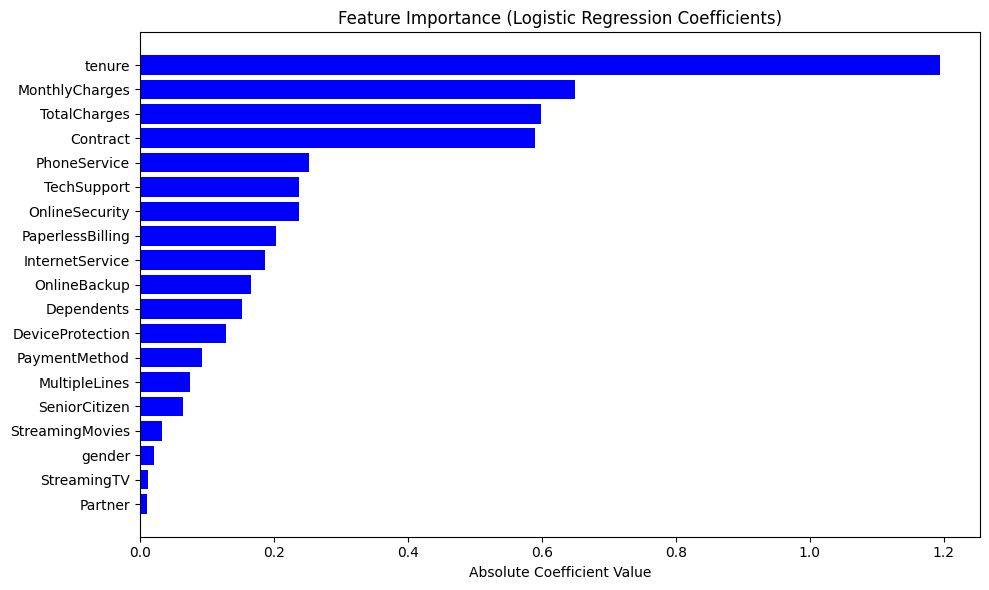

In [318]:
coefs = model_pipeline.named_steps["model"].coef_[0]

# Sort by absolute importance
importance = np.abs(coefs)
sorted_idx = np.argsort(importance)[::-1]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), importance[sorted_idx], align="center", color="blue")
plt.yticks(range(len(sorted_idx)), np.array(feature_names)[sorted_idx])
plt.xlabel("Absolute Coefficient Value")
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.gca().invert_yaxis()  # largest importance at the top
plt.tight_layout()
plt.show()

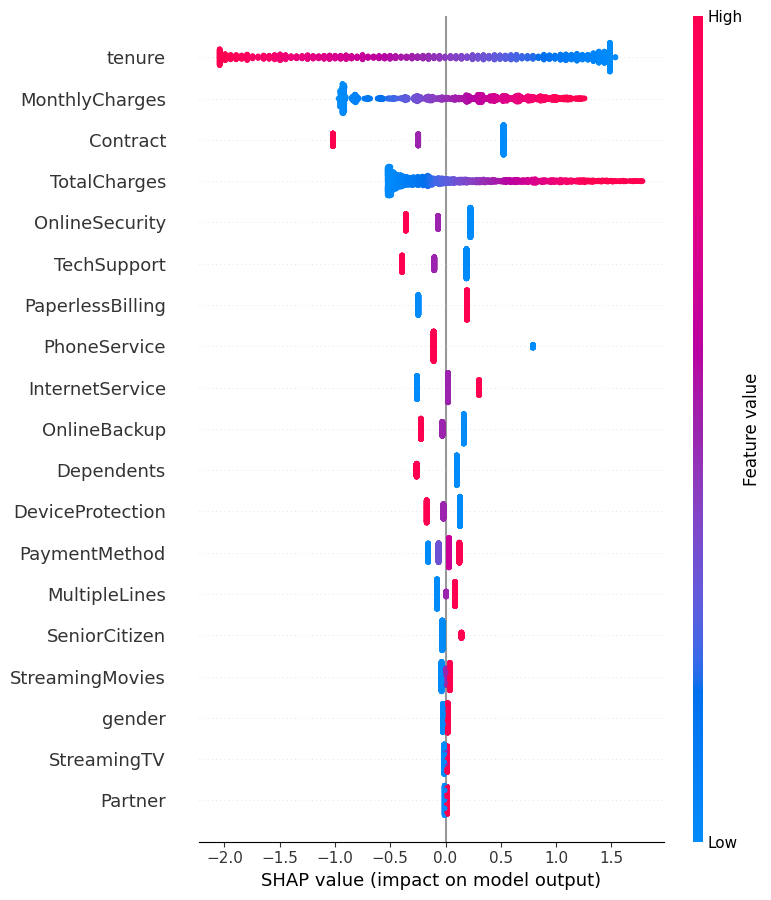

In [319]:
# 1. Transform the data using the pipeline's preprocessing steps
# We exclude the final 'model' step to get the data as the LogisticRegression sees it
preprocessor = model_pipeline[:-1]
X_test_transformed = preprocessor.transform(X_test1)

# 2. Get the feature names after preprocessing
# This ensures your SHAP plot shows "Age" or "Income" instead of "Column 1"
feature_names = categorical_features + continuous_features

# 3. Create a DataFrame for better visualization
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# 4. Use the LogisticRegression model from the pipeline
final_model = model_pipeline.named_steps['model']

# 5. Explain and Plot
explainer = shap.LinearExplainer(final_model, X_test_df)
shap_values = explainer(X_test_df)

# Visualization
shap.summary_plot(shap_values, X_test_df)

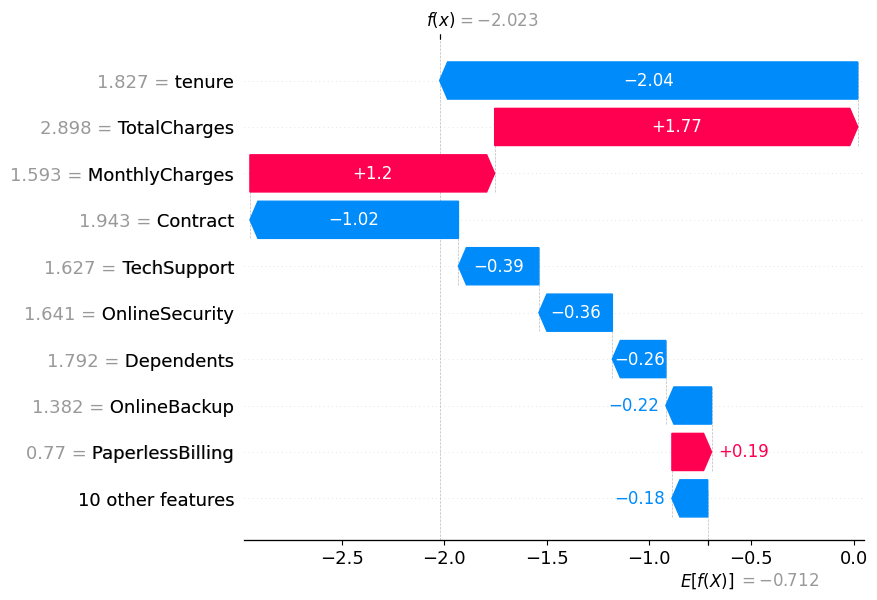

In [320]:
shap.plots.waterfall(shap_values[0])

In [321]:
joblib.dump(model_pipeline, "/content/drive/MyDrive/customer_churn/churn_model_pipeline.pkl")

['/content/drive/MyDrive/customer_churn/churn_model_pipeline.pkl']

In [322]:
df_raw.to_csv("/content/drive/MyDrive/customer_churn/df_cleaned_raw.csv", index=False)